In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('deceptive-points-aicc-round-0')

print("Path to competition files:", path)

Path to competition files: C:\Users\raian\.cache\kagglehub\competitions\deceptive-points-aicc-round-0


In [2]:
path

'C:\\Users\\raian\\.cache\\kagglehub\\competitions\\deceptive-points-aicc-round-0'

In [3]:
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LinearRegression

DATA_PATH = Path(path)
OUT_PATH = Path("./")
TRAIN_PATH = DATA_PATH / "train.csv"
TEST_PATH = DATA_PATH / "test.csv"
SUB_PATH = OUT_PATH / "submission.csv"
SOL_PATH = DATA_PATH / "solution.csv" # Not available during the competition

train_df = pd.read_csv(TRAIN_PATH)
X_train = train_df[["feature1","feature2","feature3","feature4"]].values
y_train = train_df["target"].values

test_df = pd.read_csv(TEST_PATH)
X_test = test_df[["feature1","feature2","feature3","feature4"]].values
test_ids = test_df["ID"].values

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

submission_df = pd.DataFrame({
    "ID": test_ids,
    "Target": y_pred
})
submission_df.to_csv(SUB_PATH, index=False)
print("Saved")

Saved


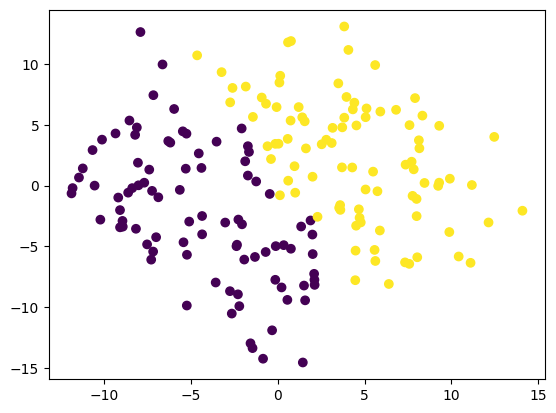

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

kmeans = KMeans(2)
labels = kmeans.fit_predict(X_train, y_train)

pca = PCA(2)
pca_train = pca.fit_transform(X_train)

plt.scatter(pca_train[:, 0], pca_train[:, 1], c=labels)

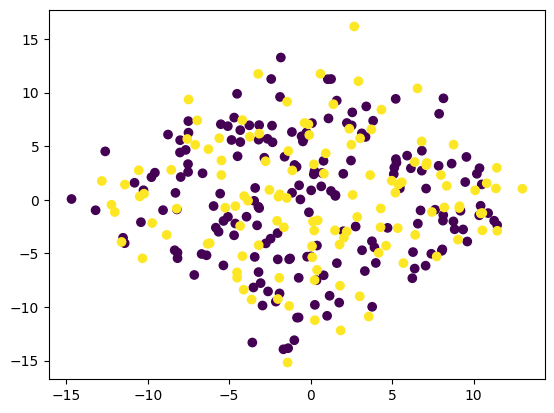

In [5]:
import numpy as np

pca = PCA(2)
pca_x = pca.fit_transform(np.concat([X_train, X_test]))
y = len(X_train) * [0] + len(X_test) * [1]
plt.scatter(pca_x[:,0], pca_x[:, 1], c=y)

[0.30365546]


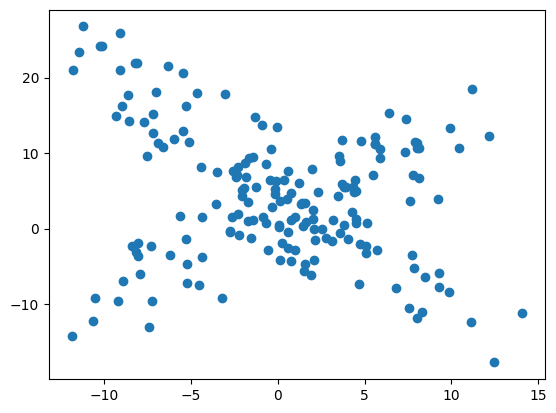

In [6]:
pca = PCA(1)
pca_train = pca.fit_transform(X_train)
plt.scatter(pca_train[:,0], y_train)
print(pca.explained_variance_ratio_)

In [7]:
from sklearn.linear_model import RANSACRegressor, LinearRegression
model = RANSACRegressor(estimator=LinearRegression())
model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",None
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionadded:: 0.18"

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_x = scaler.fit_transform(X_train)

from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(2, covariance_type='full', n_init=100, max_iter=200, tol=1e-4)

data = np.concat([scaled_x, y_train.reshape((-1, 1))], axis=1)
gmm.fit(data)

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.0001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",200
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",100
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [30]:
cluster_probs = gmm.predict_proba(data)
nearest_cluster = np.argmax(cluster_probs, axis=1)

def weighted_corr(x, y, w):
    c = np.cov(x, y, aweights=w)
    return c[0, 1] / np.sqrt(c[0, 0] * c[1, 1])

x = X_train.mean(axis=1)
teacher_id = np.argmax([weighted_corr(x, y_train, cluster_probs[:, i])
                        for i in range(cluster_probs.shape[1])])

In [34]:
y_train.shape

(180,)

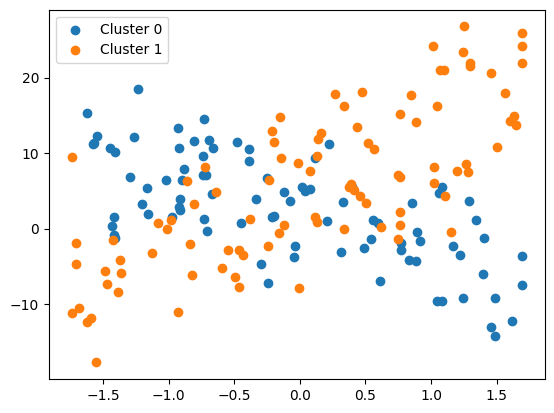

In [42]:
for k in np.unique(nearest_cluster):
    m = nearest_cluster == k
    plt.scatter(scaled_x[m, 0], y_train[m], label=f"Cluster {k}")
plt.legend()

In [43]:
from sklearn.linear_model import HuberRegressor

weights = cluster_probs[:, 1]
model = HuberRegressor()
model.fit(scaled_x, y_train, weights)

y_pred = model.predict(X_test)